<a href="https://colab.research.google.com/github/NamithaDaney/Weather-Temperature-Prediction/blob/main/DL_Assignment2_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,SimpleRNN, Dropout, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Part A: Data Understanding and Preprocessing
1. Load the dataset and explore:
* Display first 10 rows.
* Plot temperature trends over time.
* Check for missing values.

In [128]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muthuj7/weather-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'weather-dataset' dataset.
Path to dataset files: /kaggle/input/weather-dataset


In [129]:
import os

# List all files inside the downloaded kagglehub folder
files = os.listdir(path)
print("Files in directory:", files)


Files in directory: ['weatherHistory.csv']


In [130]:
# Define the absolute path to your target CSV file
csv_filename = 'weatherHistory.csv'
csv_path = os.path.join(path, csv_filename)

# Load the dataset directly into a Pandas DataFrame
df = pd.read_csv(csv_path)

df.head(10)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


In [131]:
df.shape

(96453, 12)

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [133]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [134]:
# Convert the Date column to a datetime format for correct time-series handling
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)

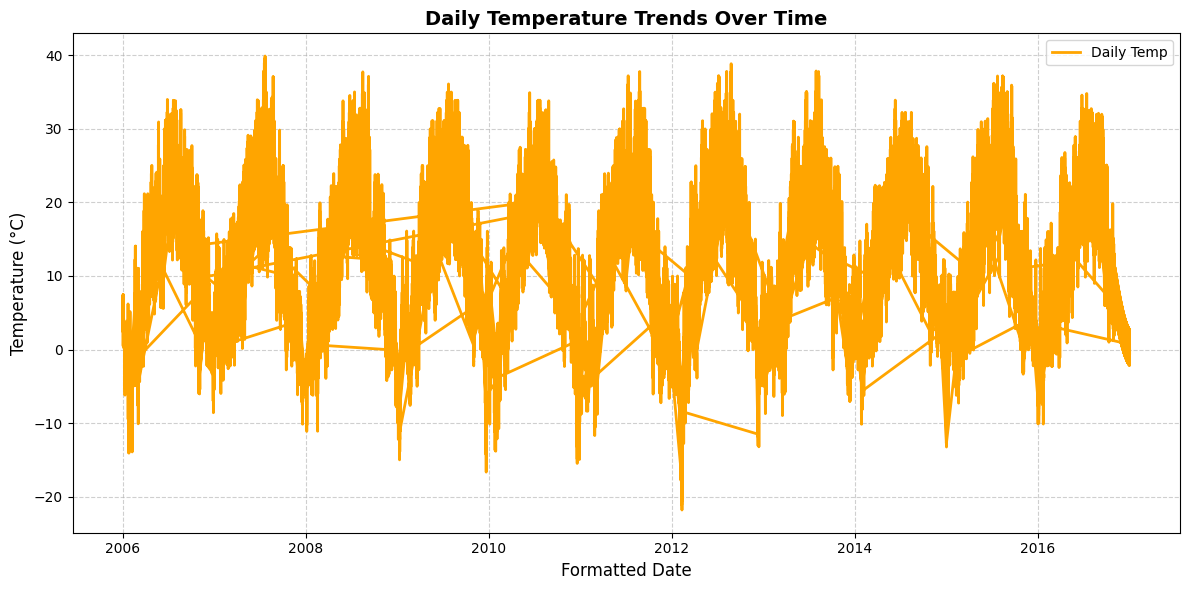

In [135]:
# Plotting the Temperature trend
plt.figure(figsize=(12, 6))
plt.plot(df['Formatted Date'], df['Temperature (C)'], color='orange', linewidth=2, label='Daily Temp')

# Formatting the graph
plt.title('Daily Temperature Trends Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Formatted Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()


In [136]:
# Check for missing values across all features
df.isnull().sum()


,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


2. Preprocess the data:
* Handle missing values (impute/remove).
* Normalize values using MinMaxScaler (so RNN converges faster).
* Create input sequences:
1. Use past 7–14 days’ weather data (temperature, humidity, wind speed)
as input.
2. Target: next day’s temperature.
* Split dataset into train, validation, and test sets.

In [137]:
#drop the null value column
df.drop(columns=['Precip Type'],inplace=True)

In [138]:
df.columns

Index(['Formatted Date', 'Summary', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')

In [140]:
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)
df = df.set_index('Formatted Date').sort_index()

In [141]:
df.head()

,Summary,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
Formatted Date,,,,,,,,,,
2005-12-31 23:00:00+00:00,Partly Cloudy,0.577778,-4.050000,0.89,17.1143,140.0,9.9820,0.0,1016.66,Mostly cloudy throughout the day.
2006-01-01 00:00:00+00:00,Mostly Cloudy,1.161111,-3.238889,0.85,16.6152,139.0,9.9015,0.0,1016.15,Mostly cloudy throughout the day.
2006-01-01 01:00:00+00:00,Mostly Cloudy,1.666667,-3.155556,0.82,20.2538,140.0,9.9015,0.0,1015.87,Mostly cloudy throughout the day.
2006-01-01 02:00:00+00:00,Overcast,1.711111,-2.194444,0.82,14.4900,140.0,9.9015,0.0,1015.56,Mostly cloudy throughout the day.
2006-01-01 03:00:00+00:00,Mostly Cloudy,1.183333,-2.744444,0.86,13.9426,134.0,9.9015,0.0,1014.98,Mostly cloudy throughout the day.


In [142]:
df_daily = df.resample('D').mean(numeric_only=True)

In [143]:
df_daily.head()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
Formatted Date,,,,,,,,
2005-12-31 00:00:00+00:00,0.577778,-4.050000,0.890000,17.114300,140.000000,9.982000,0.0,1016.660000
2006-01-01 00:00:00+00:00,4.075000,-0.174537,0.817083,21.229192,142.750000,11.348487,0.0,1011.985000
2006-01-02 00:00:00+00:00,5.263194,1.808796,0.847083,17.824713,164.583333,8.492079,0.0,1010.384167
2006-01-03 00:00:00+00:00,2.340509,0.445370,0.897083,7.726658,252.541667,9.223958,0.0,1021.170833
2006-01-04 00:00:00+00:00,2.251852,-0.663194,0.906667,12.152817,35.000000,8.352546,0.0,981.770833


In [144]:
df_daily.isnull().sum()

,0
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0
Pressure (millibars),0


In [145]:
# Select our specified features and target
features = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)']
target = 'Temperature (C)'

# Extract the values into a clean numpy array
feature_data = df_daily[features].values

print(f"Total days available after daily aggregation: {len(feature_data)}")

Total days available after daily aggregation: 4019


In [146]:
# Scale all features between 0 and 1 for optimal RNN gradient convergence
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(feature_data)

# Standalone target scaler to comfortably reverse predictions back to Celsius later
target_index = features.index(target)
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(feature_data[:, target_index].reshape(-1, 1))

MinMaxScaler()

In [147]:
# Using past 7 days of weather data to predict the next day's temperature
sequence_length = 7
X, y = [], []

for i in range(sequence_length, len(scaled_data)):
    # Input: Past 7 days across all 3 features (temp, humidity, wind)
    X.append(scaled_data[i - sequence_length:i, :])
    # Target: Next day's temperature
    y.append(scaled_data[i, target_index])

X = np.array(X)
y = np.array(y)

print(f"\nSequence Matrix Shapes -> X: {X.shape}, y: {y.shape}")


Sequence Matrix Shapes -> X: (4012, 7, 3), y: (4012,)


In [148]:
# Split chronologically (70% Train, 15% Validation, 15% Test) to prevent data leakage
total_samples = len(X)
train_end = int(total_samples * 0.70)
val_end = int(total_samples * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print(f"\n--- Chronological Data Splits Complete ---")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}  | y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}  | y_test shape:  {y_test.shape}")


--- Chronological Data Splits Complete ---
X_train shape: (2808, 7, 3) | y_train shape: (2808,)
X_val shape:   (602, 7, 3)  | y_val shape:   (602,)
X_test shape:  (602, 7, 3)  | y_test shape:  (602,)


Part B: RNN Model Development
3. Build a SimpleRNN model using TensorFlow/Keras:
* Input layer (with shape = sequence length × number of features).
* SimpleRNN layer (e.g., 32–64 units).
* Dropout layer (optional, to avoid overfitting).
* Dense layer with 1 unit (linear activation for regression).

In [149]:
sequence_len = X_train.shape[1]  # Expected: 7
num_features = X_train.shape[2]  # Expected: 3
input_shape = (sequence_len, num_features)

print(f"Defining model input layer with shape: {input_shape}")

Defining model input layer with shape: (7, 3)


In [150]:
# Construct the SimpleRNN
model_rnn = Sequential([
    Input(shape=(sequence_len, num_features)),
    SimpleRNN(units=64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(units=1, activation='linear')
])


4. Compile the model:
* Loss: Mean Squared Error (MSE).
* Optimizer: Adam.
* Metrics: Mean Absolute Error (MAE).

In [151]:
# Compile the Regression Engine ---
model_rnn.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

print("--- SimpleRNN Architecture Summary ---")
model_rnn.summary()

--- SimpleRNN Architecture Summary ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

5. Train the model on training data:
* Batch size: 32
* Epochs: 50–100

* Use validation data to monitor performance.
* Plot training vs validation loss curves.

In [152]:
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0187 - mean_absolute_error: 0.1050 - val_loss: 0.0031 - val_mean_absolute_error: 0.0435
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0086 - mean_absolute_error: 0.0745 - val_loss: 0.0033 - val_mean_absolute_error: 0.0455
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0068 - mean_absolute_error: 0.0652 - val_loss: 0.0024 - val_mean_absolute_error: 0.0389
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0062 - mean_absolute_error: 0.0620 - val_loss: 0.0026 - val_mean_absolute_error: 0.0402
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0057 - mean_absolute_error: 0.0590 - val_loss: 0.0021 - val_mean_absolute_error: 0.0360
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0050 - mean_absolute_error: 0.0555 - val_loss: 0.0019 - val_mean_absolute_error: 0.0344
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0051 - mean_absolute_error: 0.0564 - val_loss: 0.00

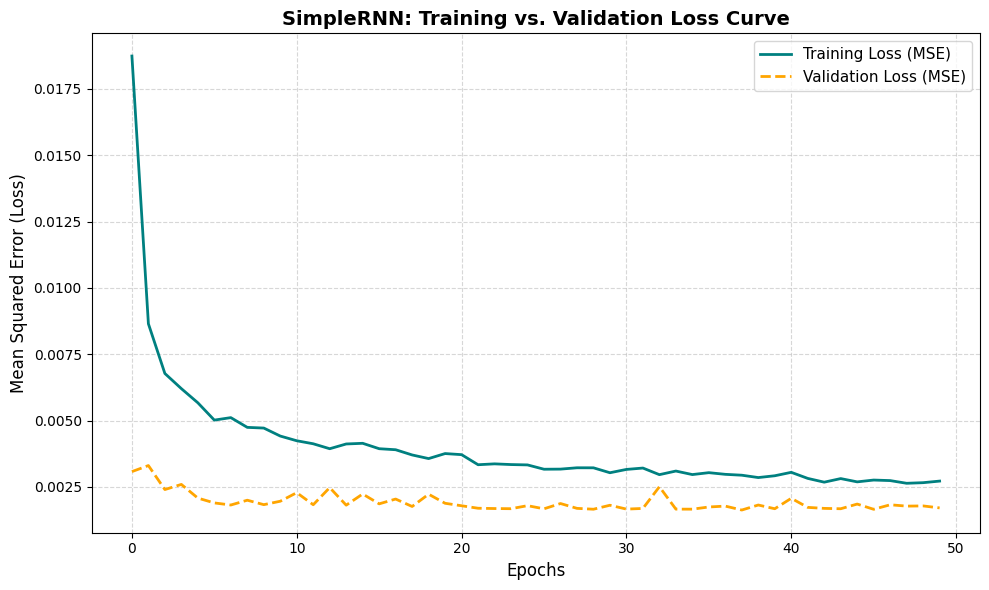

In [153]:
# Plot Training vs. Validation Loss Curves ---
plt.figure(figsize=(10, 6))

# Extract loss values from the training history dictionary
plt.plot(history_rnn.history['loss'], label='Training Loss (MSE)', color='teal', linewidth=2)
plt.plot(history_rnn.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2, linestyle='--')

# Format the visualization
plt.title('SimpleRNN: Training vs. Validation Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# Render graph cleanly
plt.tight_layout()
plt.show()

Part C: Model Evaluation & Forecasting
6. Evaluate the model on the test set:
* Calculate RMSE, MAE, and R2 score.
* Plot predicted vs actual temperatures for the test period.

In [154]:
# Model Predictions on Test Data ---
y_pred_scaled = model_rnn.predict(X_test)

# Inverse Transform back to Original Celsius Scale
y_pred_celsius = target_scaler.inverse_transform(y_pred_scaled)
y_test_celsius = target_scaler.inverse_transform(y_test.reshape(-1, 1))

mae = mean_absolute_error(y_test_celsius, y_pred_celsius)
mse = mean_squared_error(y_test_celsius, y_pred_celsius)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_celsius, y_pred_celsius)

print("=========================================")
print("         TEST SET PERFORMANCE            ")
print("=========================================")
print(f"Mean Absolute Error (MAE)      : {mae:.2f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.2f}")
print(f"R-squared Score (R²)           : {r2:.4f}")
print("=========================================")


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
         TEST SET PERFORMANCE            
Mean Absolute Error (MAE)      : 1.56
Root Mean Squared Error (RMSE) : 2.00
R-squared Score (R²)           : 0.9441


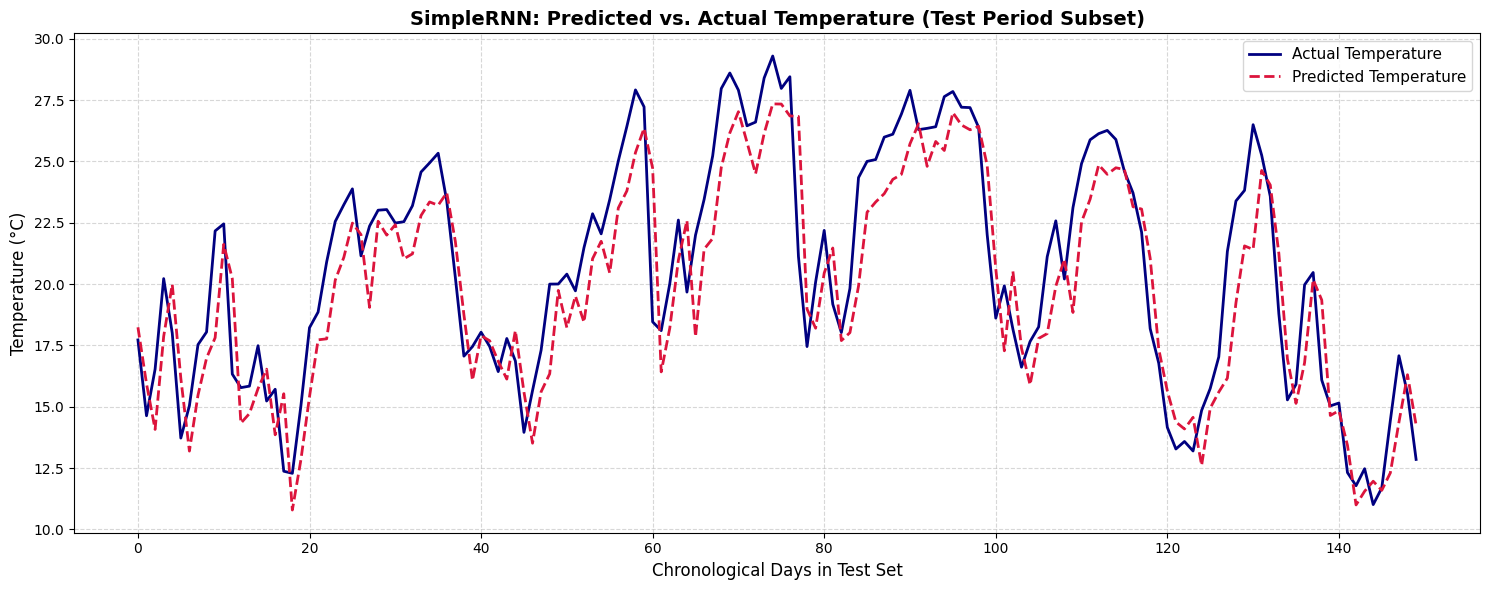

In [155]:
plt.figure(figsize=(15, 6))

# For a clearer view, we can plot a subset (e.g., first 150 days) of the test period
# Remove the slicing [:150] if you prefer to see the entire test partition at once
plt.plot(y_test_celsius[:150], label='Actual Temperature', color='navy', linewidth=2)
plt.plot(y_pred_celsius[:150], label='Predicted Temperature', color='crimson', linewidth=2, linestyle='--')

plt.title('SimpleRNN: Predicted vs. Actual Temperature (Test Period Subset)', fontsize=14, fontweight='bold')
plt.xlabel('Chronological Days in Test Set', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

7. Forecast the next 7 days of temperature using the trained model and visualize
predictions vs recent historical data.

In [156]:
# 1. Grab exactly the last 7 rows to match sequence_length = 7
last_window = scaled_data[-7:, :].copy()

future_forecasts_scaled = []
current_window = last_window.copy()

# 2. Autoregressive Loop for a 7-Day Horizon
for _ in range(7):
    # Reshape current window to match model expectation: (1, 7, 3)
    input_seq = np.expand_dims(current_window, axis=0)

    # Predict the next day's scaled temperature
    next_temp_scaled = model_rnn.predict(input_seq, verbose=0)
    future_forecasts_scaled.append(next_temp_scaled)

    # Build a clean feature array for the newly predicted day
    next_step_features = np.zeros((1, 3))

    # Use [0, 0] to extract the raw scalar value and clear the NumPy deprecation warning
    next_step_features[0, target_index] = next_temp_scaled[0, 0]

    # Fill in the non-target variables (Humidity, Wind Speed) using the last known day's values
    for idx in range(3):
        if idx != target_index:
            next_step_features[0, idx] = current_window[-1, idx]

    # Slide the 7-day window forward
    current_window = np.vstack([current_window[1:], next_step_features])

# 3. Inverse Transform & Calculate Future Dates
future_forecasts_celsius = target_scaler.inverse_transform(np.array(future_forecasts_scaled).reshape(-1, 1)).flatten()
last_historical_date = df_daily.index[-1]
forecast_dates = pd.date_range(start=last_historical_date + pd.Timedelta(days=1), periods=7)

# 4. Print out the Textual Forecast Results
print("\n=========================================")
print("   UPCOMING 7-DAY TEMPERATURE FORECAST ")
print("=========================================")
for date, temp in zip(forecast_dates, future_forecasts_celsius):
    print(f"{date.strftime('%Y-%m-%d (%A)')} : {temp:.2f} °C")



   UPCOMING 7-DAY TEMPERATURE FORECAST 
2017-01-01 (Sunday) : 0.42 °C
2017-01-02 (Monday) : 0.74 °C
2017-01-03 (Tuesday) : 0.98 °C
2017-01-04 (Wednesday) : 1.16 °C
2017-01-05 (Thursday) : 1.31 °C
2017-01-06 (Friday) : 1.44 °C
2017-01-07 (Saturday) : 1.56 °C


In [157]:
# Grab the last 7 days of actual historical data to display as context
historical_context_scaled = scaled_data[-7:, target_index].reshape(-1, 1)
historical_context_celsius = target_scaler.inverse_transform(historical_context_scaled)

# Generate Timestamps for the Forecast Horizon
forecast_dates = pd.date_range(start=last_historical_date + pd.Timedelta(days=1), periods=7)
historical_dates = df_daily.index[-7:]

# Convert the date arrays explicitly to datetime objects before plotting
historical_dates = pd.to_datetime(historical_dates)
forecast_dates = pd.to_datetime(forecast_dates)


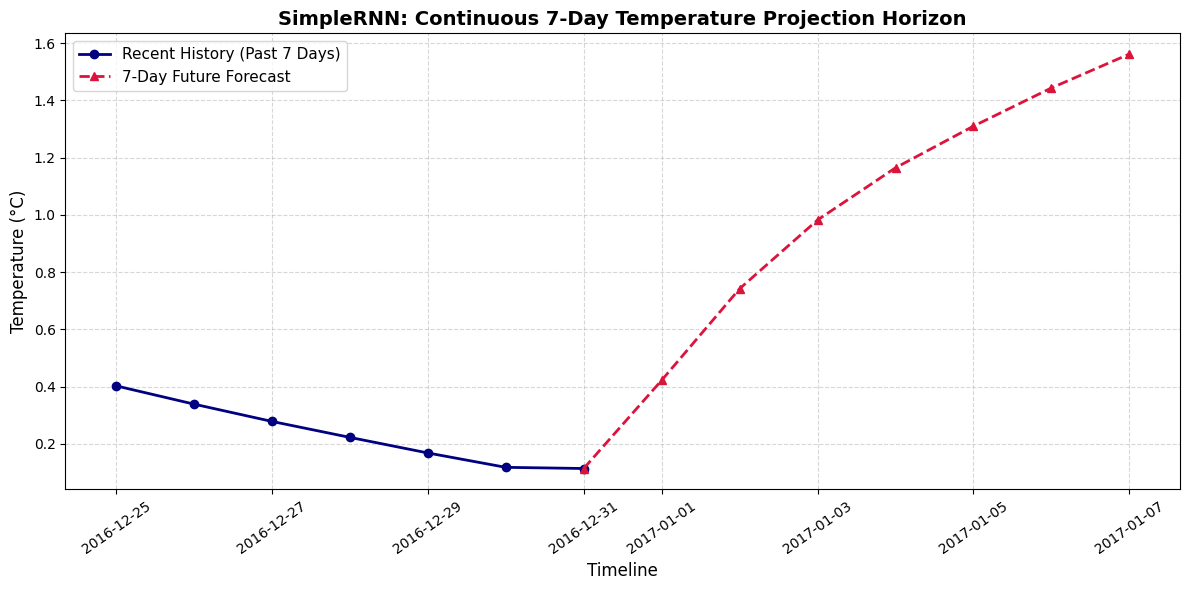

In [160]:
# Create a continuous forecast line that touches the historical line
extended_forecast_dates = np.insert(forecast_dates, 0, historical_dates[-1])
extended_forecast_celsius = np.insert(future_forecasts_celsius, 0, historical_context_celsius[-1])

plt.figure(figsize=(12, 6))

# Plot history
plt.plot(historical_dates, historical_context_celsius, label='Recent History (Past 7 Days)', color='navy', marker='o', linewidth=2)

# Plot forecast starting exactly where history ends
plt.plot(extended_forecast_dates, extended_forecast_celsius, label='7-Day Future Forecast', color='crimson', marker='^', linestyle='--', linewidth=2)

# Format the chart using proper datetime spacing
plt.title('SimpleRNN: Continuous 7-Day Temperature Projection Horizon', fontsize=14, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# Rotate labels safely
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


In [159]:
# Save the model architecture and weights together
model_rnn.save('best_weather_rnn_model.keras')
print("Model saved successfully as 'best_weather_rnn_model.keras'!")


Model saved successfully as 'best_weather_rnn_model.keras'!
